# Feature : score de ratio d'énergie en fréquences

Si le score est élevé : l'image contient beaucoup d'info/énergie dans les hautes fréquences càd qu'il y a bcp de détails !

Si le score est faible : l'image est plutôt homogène, càd peu de détails


In [1]:
from fastai.vision.all import *

In [ ]:
# git clone --depth 1 permet de dl le dernier commit
!git clone --depth 1 https://github.com/SartajBhuvaji/Brain-Tumor-Classification-DataSet.git ./dataset

fatal: destination path './dataset' already exists and is not an empty directory.


In [14]:
# 2. On définit nos chemins vers les dossiers qui nous intéressent
path_sain = Path('./dataset/Training/no_tumor')
path_tumeur = Path('./dataset/Training/glioma_tumor')

# 3. Récupérer les images
files_sain = get_image_files(path_sain)
files_tumeur = get_image_files(path_tumeur)

# 4. Pour ne pas traiter tout le dataset et tester rapidement le score FFT
fichiers_test_sain = files_sain[:50]
fichiers_test_tumeur = files_tumeur[:50]

print(f"Nombre total d'images saines : {len(files_sain)}")
print(f"Nombre d'images conservées pour le test rapide : {len(fichiers_test_sain)}")

Nombre total d'images saines : 395
Nombre d'images conservées pour le test rapide : 50


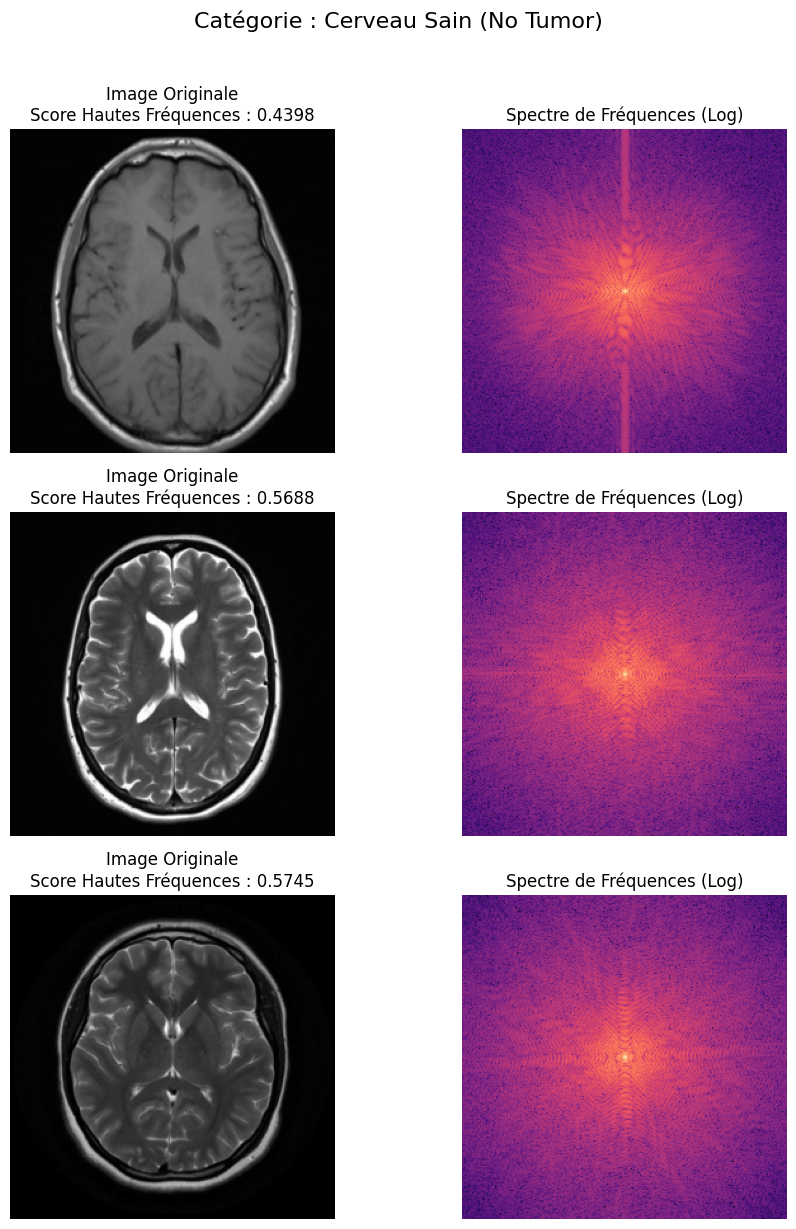

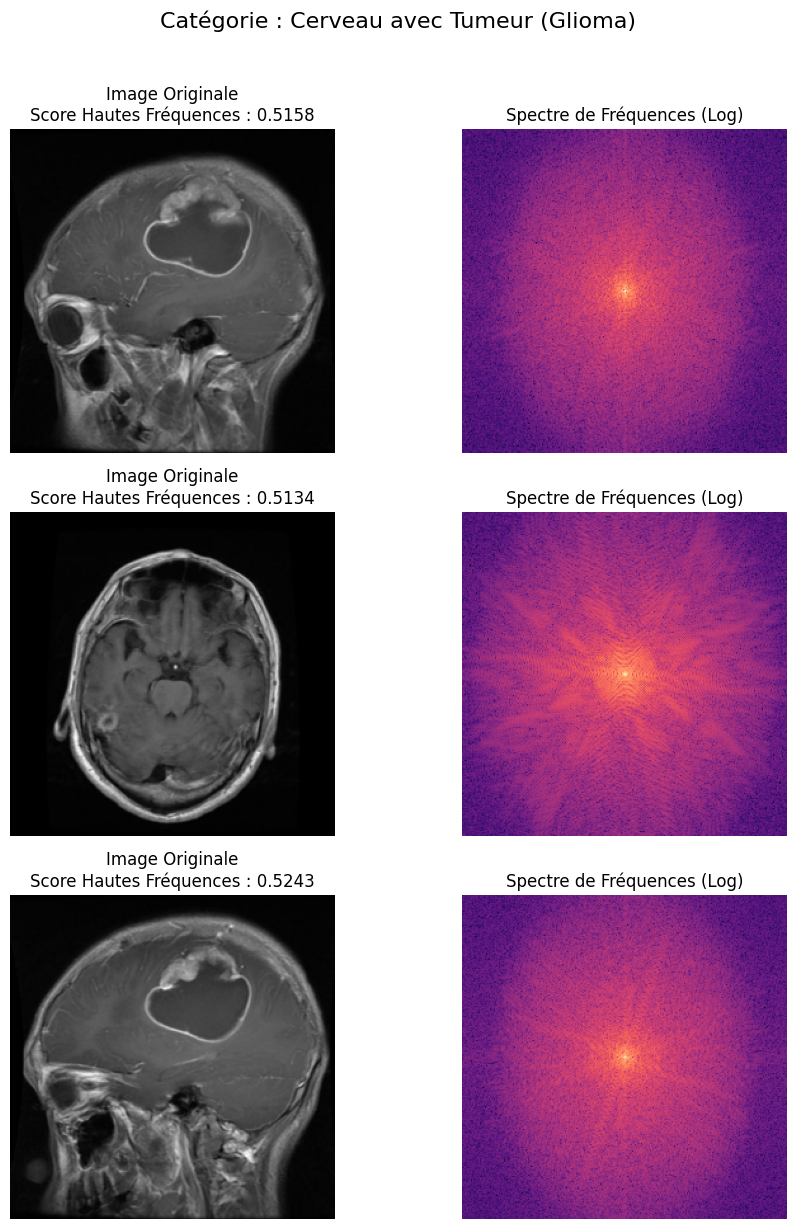

In [ ]:
from torchvision.io import read_image, ImageReadMode
import torchvision.transforms.functional as tfms
import torch
import torch.fft

# 1. Fonction de calcul du score et du spectre
def compute_fft_score(img_path, radius=30):
    # Charger l'image en niveaux de gris et redimensionner (256x256)
    img = read_image(img_path, mode=ImageReadMode.GRAY)
    img = tfms.resize(img, [256, 256], antialias=True)

    # img est un tenseur 3D, il faut écraser le canal en (256,256)
    img = img.squeeze()

    # Calcul de la FFT 2D et centrage 
    f = torch.fft.fft2(img)
    fshift = torch.fft.fftshift(f)
    magnitude_spectrum = torch.abs(fshift)

    # Création du masque circulaire pour les basses fréquences : permet un semblant de segmentation
    rows, cols = img.shape
    crow, ccol = rows // 2, cols // 2

    # Utilisation de torch.arange pour recréer l'équivalent de np.ogrid
    y = torch.arange(-crow, rows - crow).view(-1, 1)
    x = torch.arange(-ccol, cols - ccol).view(1, -1)
    mask = x**2 + y**2 <= radius**2

    # Calcul des énergies (Hautes Fréquences / Total) 
    total_energy = torch.sum(magnitude_spectrum)
    lf_energy = torch.sum(magnitude_spectrum[mask])
    hf_energy = total_energy - lf_energy

    # Calcul du Ratio (Score) - .item() permet de convertir le Tenseur scalaire en float standard
    hf_ratio = (hf_energy / total_energy).item() if total_energy > 0 else 0

    # Transformation logarithmique pour la visualisation du spectre
    vis_spectrum = 20 * torch.log(magnitude_spectrum + 1)

    return img.numpy(), vis_spectrum.numpy(), hf_ratio

# 2. Fonction pour afficher une grille d'images
def visualize_samples(paths, class_name, num_samples=3):
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 4 * num_samples))
    fig.suptitle(f"Catégorie : {class_name}", fontsize=16, y=1.02)

    for i in range(num_samples):
        img, spectrum, score = compute_fft_score(paths[i])


        # Affichage de l'image originale
        axes[i, 0].imshow(img, cmap='gray')
        axes[i, 0].set_title(f"Image Originale\nScore Hautes Fréquences : {score:.4f}")
        axes[i, 0].axis('off')
    
        # Affichage du spectre
        axes[i, 1].imshow(spectrum, cmap='magma') # 'magma' donne un beau rendu pour les spectres
        axes[i, 1].set_title("Spectre de Fréquences (Log)")
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

# 3. Exécution sur 3 images saines et 3 images avec tumeur
visualize_samples(files_sain, "Cerveau Sain (No Tumor)", num_samples=3)
visualize_samples(files_tumeur, "Cerveau avec Tumeur (Glioma)", num_samples=3)

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def crop_otsu_and_fft(img_path, radius=30):
    # 1. Charger l'image
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

    # 2. Seuillage d'Otsu
    blur = cv2.GaussianBlur(img, (5, 5), 0)
    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # 3. Trouver les contours pour créer la Bounding Box
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest_contour)
        cropped_img = img[y:y+h, x:x+w]
    else:
        cropped_img = img

    # 4. Redimensionner le recadrage
    cropped_img = cv2.resize(cropped_img, (256, 256))

    # 5. Calcul de la FFT
    f = np.fft.fft2(cropped_img)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = np.abs(fshift)

    # Masque circulaire pour séparer les fréquences
    rows, cols = cropped_img.shape
    crow, ccol = rows // 2, cols // 2
    Y, X = np.ogrid[-crow:rows-crow, -ccol:cols-ccol]
    mask = X**2 + Y**2 <= radius**2

    # Calcul du score HFR
    total_energy = np.sum(magnitude_spectrum)
    lf_energy = np.sum(magnitude_spectrum[mask])
    hf_energy = total_energy - lf_energy
    hf_ratio = hf_energy / total_energy if total_energy > 0 else 0

    vis_spectrum = 20 * np.log(magnitude_spectrum + 1)

    # ---------------------------------------------------------
    # Filtre Passe-Haut (HPF) et Reconstitution (IFFT)
    # ---------------------------------------------------------
    fshift_filtered = np.copy(fshift)
    fshift_filtered[mask] = 0 # Mise à zéro des basses fréquences (composante continue incluse)

    f_ishift = np.fft.ifftshift(fshift_filtered)
    img_back = np.fft.ifft2(f_ishift)
    img_hpf = np.abs(img_back)
    # ---------------------------------------------------------

    return cropped_img, vis_spectrum, hf_ratio, img_hpf

def visualize_cropped_samples(paths, class_name, num_samples=3):
    # Passage à 3 colonnes et ajustement de la largeur de la figure (15 au lieu de 10)
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 4 * num_samples))
    fig.suptitle(f"{class_name} (Après Recadrage Otsu & Filtrage)", fontsize=16, y=1.02)

    # Gestion du cas où num_samples = 1 (axes devient 1D)
    if num_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(num_samples):
        # Récupération de la 4ème variable : img_hpf
        img_cropped, spectrum, score, img_hpf = crop_otsu_and_fft(paths[i])

        # Colonne 1 : Image Rognée
        axes[i, 0].imshow(img_cropped, cmap='gray')
        axes[i, 0].set_title(f"Image Rognée\nNouveau Score : {score:.4f}")
        axes[i, 0].axis('off')

        # Colonne 2 : Spectre
        axes[i, 1].imshow(spectrum, cmap='magma')
        axes[i, 1].set_title("Spectre de Fréquences (Log)")
        axes[i, 1].axis('off')

        # Colonne 3 : Image reconstruite (Filtre Passe-Haut)
        axes[i, 2].imshow(img_hpf, cmap='gray')
        axes[i, 2].set_title("Reconstruction Passe-Haut (IFFT)")
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

# Test sur nos images
visualize_cropped_samples(fichiers_test_sain, "Cerveau Sain", num_samples=2)
visualize_cropped_samples(fichiers_test_tumeur, "Cerveau avec Tumeur", num_samples=2)

ModuleNotFoundError: No module named 'cv2'